In [1]:
!pip install --upgrade torchao
!pip install -U bitsandbytes>=0.46.1
!pip install trl -q

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns

import torch

In [4]:
DATA_DIR = '../data/'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

## Data

In [5]:
dataset = pd.read_csv(DATA_DIR + 'text_dataset.csv', encoding='utf-8')
dataset.head()

,id,timestamp,text
0,0,1712998082,А зач
1,1,1712998089,Есть же петрушка
2,2,1712998092,Ну в овсеми
3,3,1712998095,Там не все
4,4,1712998108,Ааа


### Filtering NaNs

In [6]:
dataset['next_text'] = dataset['text'].shift(-1)
dataset['delta_time'] = - dataset['timestamp'] + dataset['timestamp'].shift(-1)
dataset

,id,timestamp,text,next_text,delta_time
0,0,1712998082,А зач,Есть же петрушка,7.0
1,1,1712998089,Есть же петрушка,Ну в овсеми,3.0
2,2,1712998092,Ну в овсеми,Там не все,3.0
3,3,1712998095,Там не все,Ааа,13.0
4,4,1712998108,Ааа,Типа ещё сииимёёён,8.0
...,...,...,...,...,...
151993,151993,1787512789,посмотрим,как же там идет экспорт сообщений,266.0
151994,151994,1787513055,как же там идет экспорт сообщений,полчаса,2.0
151995,151995,1787513057,полчаса,NaN,7.0
151996,151996,1787513064,NaN,мегапон,5.0


In [7]:
dataset.dropna(inplace=True)
dataset.__len__()

128642

### Filtering long reply pairs

<Axes: xlabel='delta_time', ylabel='Count'>

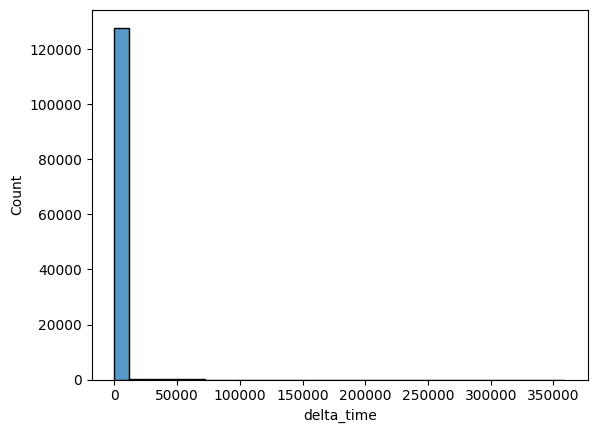

In [8]:
sns.histplot(dataset['delta_time'], bins=30)

<Axes: xlabel='delta_time', ylabel='Count'>

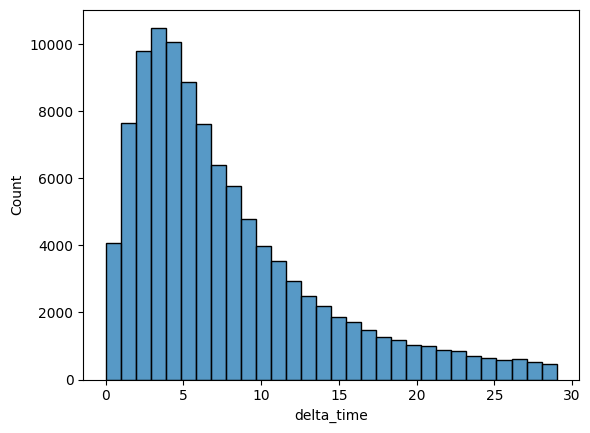

In [9]:
dt = dataset['delta_time']
dataset = dataset[dt < 30]
sns.histplot(dataset['delta_time'], bins=30)

In [10]:
dataset.drop(columns=['delta_time', 'timestamp'], inplace=True)
dataset.__len__()

C:\Users\SamWin\AppData\Local\Temp\ipykernel_22532\4237814809.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset.drop(columns=['delta_time', 'timestamp'], inplace=True)


105469

### Filtering long texts

C:\Users\SamWin\AppData\Local\Temp\ipykernel_22532\1722853586.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['text_len'] = dataset['text'].str.len() + dataset['next_text'].str.len()


<Axes: xlabel='text_len', ylabel='Count'>

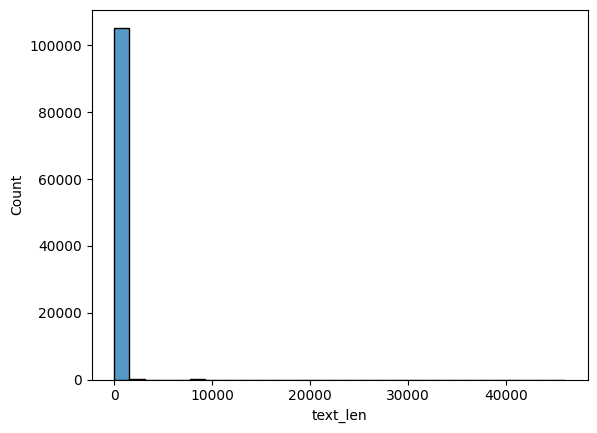

In [11]:
dataset['text_len'] = dataset['text'].str.len() + dataset['next_text'].str.len()

sns.histplot(dataset['text_len'], bins=30)

<Axes: xlabel='text_len', ylabel='Count'>

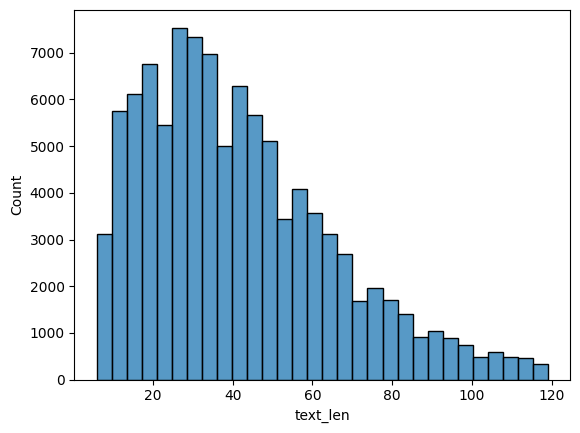

In [12]:
threshold = 4 * 30 # 100 symbols
tl = dataset['text_len']
dataset = dataset[(5 < tl) & (tl < threshold) & (dataset['next_text'].str.len() > 0)]

sns.histplot(dataset['text_len'], bins=30)

In [13]:
dataset.drop(columns=['text_len', 'id'], inplace=True)
dataset

,text,next_text
0,А зач,Есть же петрушка
1,Есть же петрушка,Ну в овсеми
2,Ну в овсеми,Там не все
3,Там не все,Ааа
4,Ааа,Типа ещё сииимёёён
...,...,...
151989,довой довой,ну бота я точно навайбкожу
151990,ну бота я точно навайбкожу,а вот берта можно зафтшить
151991,а вот берта можно зафтшить,ну или гпт
151992,ну или гпт,посмотрим


In [14]:
dataset.reset_index(inplace=True)
dataset.drop(columns=['index'], inplace=True)
dataset

,text,next_text
0,А зач,Есть же петрушка
1,Есть же петрушка,Ну в овсеми
2,Ну в овсеми,Там не все
3,Там не все,Ааа
4,Ааа,Типа ещё сииимёёён
...,...,...
100765,довой довой,ну бота я точно навайбкожу
100766,ну бота я точно навайбкожу,а вот берта можно зафтшить
100767,а вот берта можно зафтшить,ну или гпт
100768,ну или гпт,посмотрим


### Dataset formatting for SFTTrainer

In [15]:
def preprocess_format(example):
    return {
        "prompt": [{'role': 'user', 'content': example['text']}],
        "completion": [{'role': 'assistant', 'content': example['next_text']}],
    }


preprocess_format(dataset.iloc[0])

{'prompt': [{'role': 'user', 'content': 'А зач'}],
 'completion': [{'role': 'assistant', 'content': 'Есть же петрушка'}]}

In [16]:
dataset = [preprocess_format(dataset.iloc[i]) for i in range(len(dataset))]
dataset[:10]

[{'prompt': [{'role': 'user', 'content': 'А зач'}],
  'completion': [{'role': 'assistant', 'content': 'Есть же петрушка'}]},
 {'prompt': [{'role': 'user', 'content': 'Есть же петрушка'}],
  'completion': [{'role': 'assistant', 'content': 'Ну в овсеми'}]},
 {'prompt': [{'role': 'user', 'content': 'Ну в овсеми'}],
  'completion': [{'role': 'assistant', 'content': 'Там не все'}]},
 {'prompt': [{'role': 'user', 'content': 'Там не все'}],
  'completion': [{'role': 'assistant', 'content': 'Ааа'}]},
 {'prompt': [{'role': 'user', 'content': 'Ааа'}],
  'completion': [{'role': 'assistant', 'content': 'Типа ещё сииимёёён'}]},
 {'prompt': [{'role': 'user', 'content': 'Типа ещё сииимёёён'}],
  'completion': [{'role': 'assistant', 'content': 'Да'}]},
 {'prompt': [{'role': 'user', 'content': 'Да'}],
  'completion': [{'role': 'assistant', 'content': 'И Андрей'}]},
 {'prompt': [{'role': 'user', 'content': 'И Андрей'}],
  'completion': [{'role': 'assistant', 'content': 'Сергеевич'}]},
 {'prompt': [{'rol

In [17]:
from datasets import Dataset

dataset = Dataset.from_list(dataset)
dataset

Dataset({
    features: ['prompt', 'completion'],
    num_rows: 100770
})

### Train/test splitting

In [18]:
from sklearn.model_selection import train_test_split

dataset = dataset.train_test_split(test_size=0.1, shuffle=True)

## LM

### Loading model and processor

In [19]:
from transformers import Qwen3ForCausalLM, AutoTokenizer, BitsAndBytesConfig, TrainingArguments

model_name = 'Qwen/Qwen3-0.6B'

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",      # Normal Float 4 - лучший выбор для QLoRA
    bnb_4bit_compute_dtype=torch.float16, # T4 не поддерживает bfloat16!
    bnb_4bit_use_double_quant=True, # Дополнительная экономия памяти
)

model = Qwen3ForCausalLM.from_pretrained(
    model_name,
    device_map='auto',
    quantization_config=bnb_config
)

tokenizer = AutoTokenizer.from_pretrained(model_name)

W0824 15:33:08.177000 22532 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [20]:
from peft import LoraConfig, TaskType, get_peft_model

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    inference_mode=False,
    target_modules=["q_proj", "v_proj"],
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
)

model = get_peft_model(model, lora_config)

model.print_trainable_parameters()

trainable params: 1,146,880 || all params: 597,196,800 || trainable%: 0.1920


### SFT

In [ ]:
from trl import SFTTrainer

arguments = TrainingArguments(
    eval_strategy='steps',
    eval_steps=500,
    eval_on_start=True,
    per_device_train_batch_size = 8,
    max_steps = 5000,
    logging_steps=50,
)

trainer = SFTTrainer(
    model=model,
    train_dataset=dataset['train'],
    eval_dataset=dataset['test'],
    args=arguments,
)

Tokenizing train dataset:   0%|          | 0/90693 [00:00<?, ? examples/s]

KeyboardInterrupt: 

In [ ]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.
c:\Users\SamWin\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss,Validation Loss


KeyboardInterrupt: 

### Testing

In [26]:
prompt = "кто такой семен"
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
outputs = model.generate(
    **inputs,
    max_length=50,
    temperature=0.8,
    pad_token_id=tokenizer.pad_token_id, # Теперь он равен 151643
    eos_token_id=tokenizer.eos_token_id,
)
print('Model reply:\n', tokenizer.decode(outputs[0], skip_special_tokens=True))

Model reply:
 кто такой семен? А) птицам, б) животам, в) кормам? Или, допустим, ошибка? Нужно дать ответ.
Давайте разберемся, что такое


In [164]:
test = "привет мир"
ids = tokenizer.encode(test)
decoded = tokenizer.decode(ids, skip_special_tokens=True)
print(f"Original: {test}")
print(f"Decoded:  {decoded}")
print(f"IDs:      {ids}")

Original: привет мир
Decoded:  привет мир
IDs:      [124436, 26991, 8178, 137144]


### Saving model

In [ ]:
from peft import PeftModel

base_model = Qwen3ForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(model_name)

peft_model = PeftModel.from_pretrained(base_model, "trainer_output/checkpoint-2000")

merged_model = peft_model.merge_and_unload()

merged_model.save_pretrained("./merged/qwen_merged")
tokenizer.save_pretrained("./merged/qwen_merged")

`torch_dtype` is deprecated! Use `dtype` instead!


ValueError: Can't find 'adapter_config.json' at 'trainer_output/checkpoint-2000'